# Segmentation Prediction Visualizer
Displays input patches alongside predicted masks side by side.

In [1]:
# ── CONFIG — edit these paths ─────────────────────────────────────────────────
CONFIG_PATH     = "configs/segnet.yaml"
CHECKPOINT_PATH = "/home/rajaj/Project/Alex_project/seg_framework/logs/segnet_dataset/20260605_234346/fold_1/checkpoints/best_model.pth"
IMAGES_DIR      = "/data_55T_2/Raja/SEGMENTATION/test/patches"      # folder with input patches
N_DISPLAY       = 8                       # number of patches to display
DEVICE          = "cuda:0"               # or 'cpu'
RANDOM_SAMPLE   = True                   # True = random pick, False = first N

# ── CONFIG for test set visualisation (Cell 9+) ───────────────────────────────
MASKS_DIR       = "/data_55T_2/Raja/SEGMENTATION/test/masks"  # ground truth masks
N_DISPLAY_TEST  = 8                       # number of test samples to display
RANDOM_TEST     = True                    # True = random pick from test split
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from torch.amp import autocast
import torchvision.transforms.functional as TF

from utils.config  import load_config
from utils.dataset import get_splits
from modules       import get_model

print("Imports OK")

/home/rajaj/anaconda3/envs/wsi_mil_classification/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


In [3]:
# ── Load config and model ─────────────────────────────────────────────────────
cfg    = load_config(CONFIG_PATH)
device = torch.device(DEVICE if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = get_model(cfg)
ckpt  = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.to(device).eval()
print(f"Model : {cfg['model']['name'].upper()}")
print(f"Epoch : {ckpt.get('epoch', 'unknown')}")
if "metrics" in ckpt:
    print(f"Saved metrics: {ckpt['metrics']}")

Device: cuda:0
Model : SEGNET
Epoch : 100
Saved metrics: {'train_loss': 0.4402618469297886, 'train_acc': 0.8976959705352783, 'train_iou': 0.7669867336216223, 'train_dice': 0.8553805160744495, 'val_loss': 0.45002879202365875, 'val_acc': 0.8935819625854492, 'val_iou': 0.7789380960861558, 'val_dice': 0.8670821287007829}


In [4]:
# ── Collect image paths ───────────────────────────────────────────────────────
IMG_EXT = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}
all_paths = sorted([p for p in Path(IMAGES_DIR).iterdir()
                    if p.suffix.lower() in IMG_EXT])
print(f"Total patches found: {len(all_paths)}")

if RANDOM_SAMPLE:
    selected = random.sample(all_paths, min(N_DISPLAY, len(all_paths)))
else:
    selected = all_paths[:N_DISPLAY]
print(f"Selected {len(selected)} patches for display")

Total patches found: 86
Selected 8 patches for display


In [5]:
# ── Preprocess + run inference ────────────────────────────────────────────────
img_size = tuple(cfg["dataset"].get("img_size", [512, 512]))
amp      = cfg["training"].get("amp", True)

originals, predictions = [], []

with torch.no_grad():
    for path in selected:
        orig = Image.open(path).convert("RGB")
        orig = orig.resize((img_size[1], img_size[0]), Image.BILINEAR)
        originals.append(np.array(orig))

        tensor = TF.to_tensor(orig)
        tensor = TF.normalize(tensor, [0.485, 0.456, 0.406],
                                       [0.229, 0.224, 0.225])
        tensor = tensor.unsqueeze(0).to(device)

        with autocast('cuda', enabled=amp and device.type == 'cuda'):
            logits = model(tensor)

        pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()
        predictions.append(pred)

print(f"Inference done. Prediction shape: {predictions[0].shape}")
print(f"Unique predicted classes: {np.unique(np.concatenate([p.flatten() for p in predictions]))}")

Inference done. Prediction shape: (512, 512)
Unique predicted classes: [0 1]


In [6]:
# ── Colormap for multi-class masks ────────────────────────────────────────────
CLASS_COLORS = [
    (0,   0,   0),    # class 0 — background (black)
    (255, 255, 255),  # class 1 — foreground (white)
    (255, 0,   0),    # class 2 — red
    (0,   255, 0),    # class 3 — green
    (0,   0,   255),  # class 4 — blue
]
CLASS_NAMES = [f"Class {i}" for i in range(cfg["model"]["n_classes"])]

def colorize_mask(pred, colors):
    h, w  = pred.shape
    rgb   = np.zeros((h, w, 3), dtype=np.uint8)
    for cls_idx, color in enumerate(colors):
        rgb[pred == cls_idx] = color
    return rgb

colored_preds = [colorize_mask(p, CLASS_COLORS) for p in predictions]

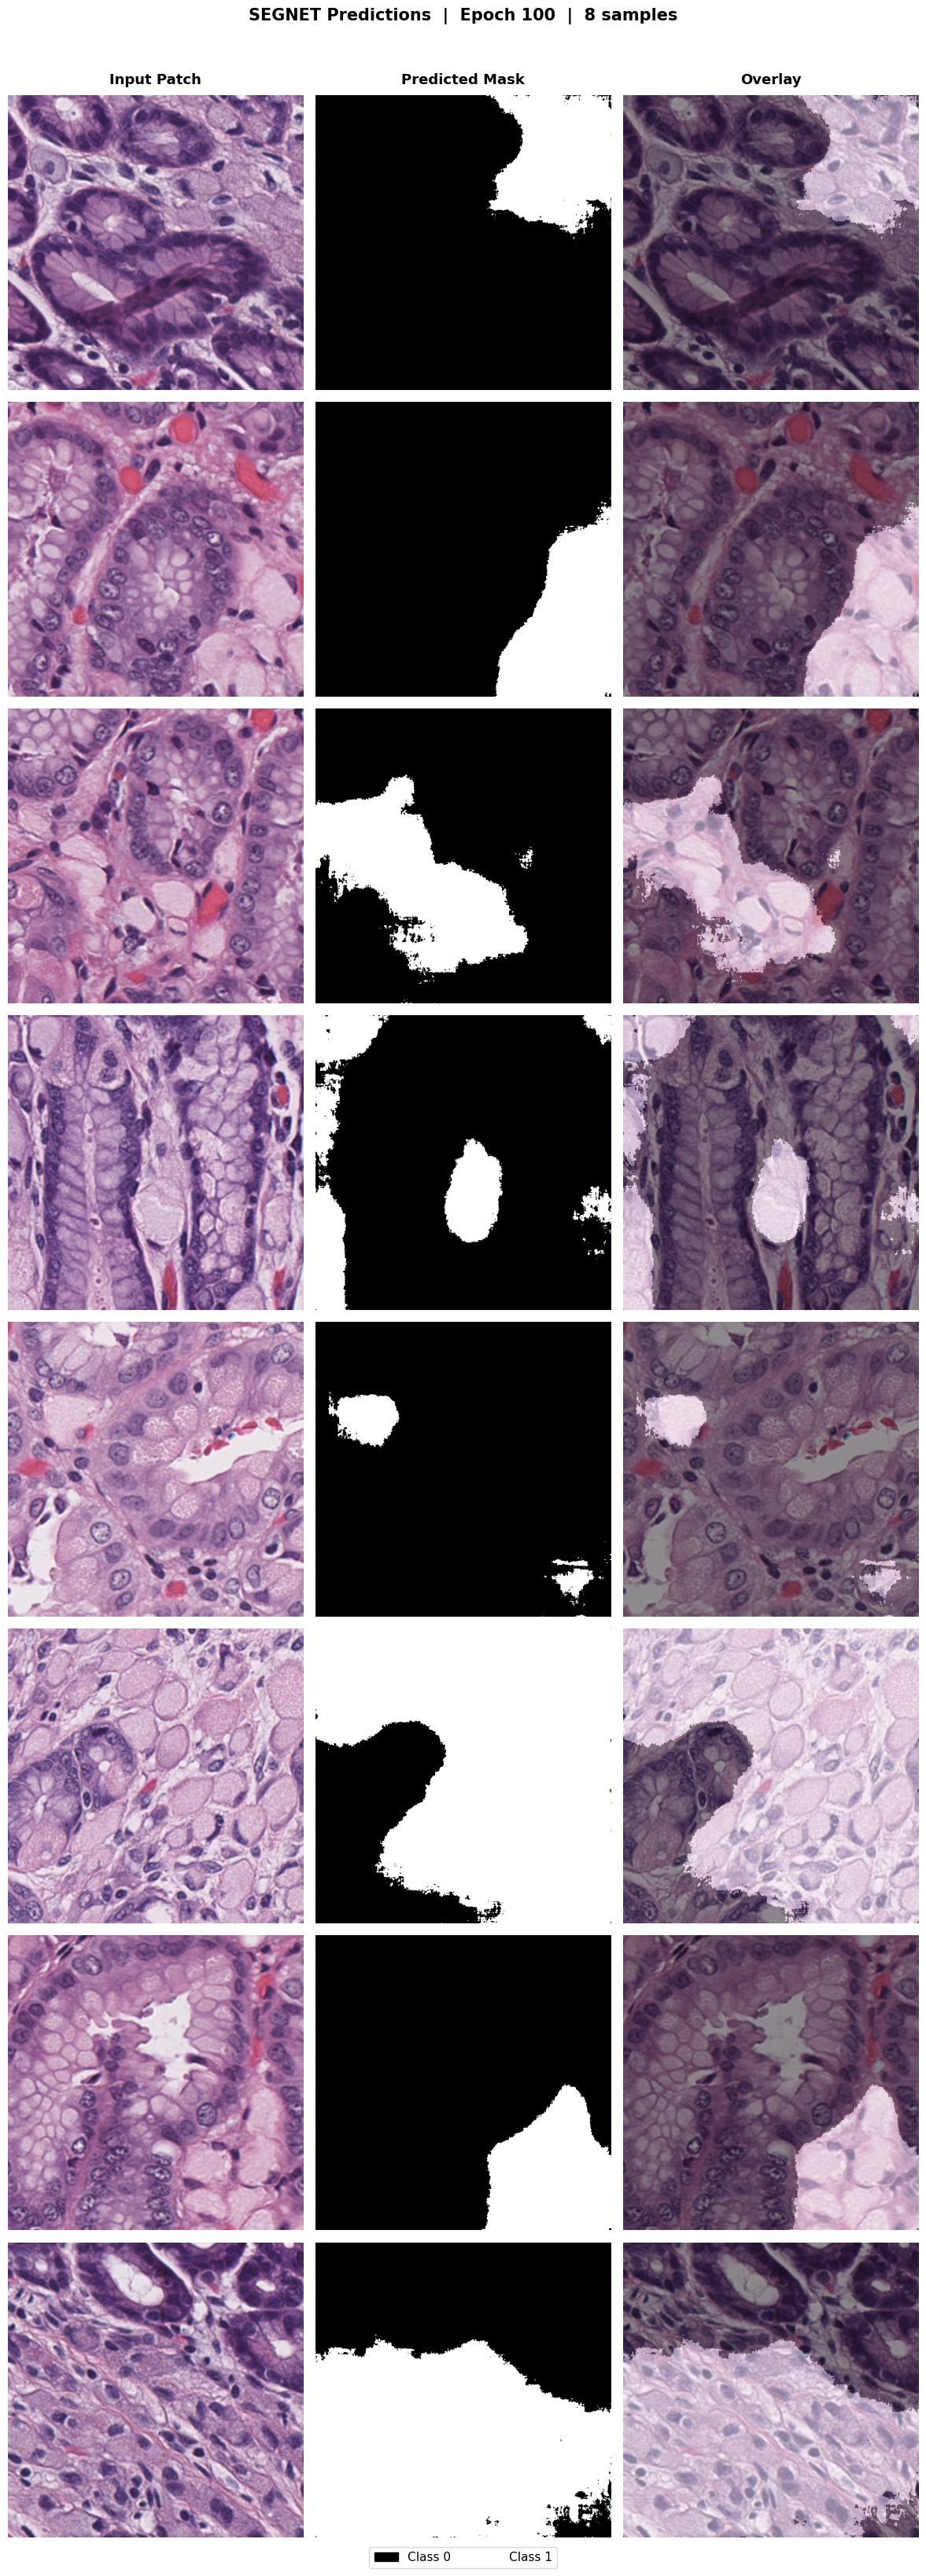

Saved: logs/predictions_grid.png


In [7]:
# ── Plot: Input | Predicted Mask | Overlay ────────────────────────────────────
n      = len(selected)
n_cols = 3
fig, axes = plt.subplots(n, n_cols, figsize=(n_cols * 4, n * 4))

if n == 1:
    axes = axes[np.newaxis, :]

col_titles = ["Input Patch", "Predicted Mask", "Overlay"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight="bold", pad=10)

for row, (orig, pred_rgb, path) in enumerate(zip(originals, colored_preds, selected)):
    axes[row, 0].imshow(orig)
    axes[row, 0].set_ylabel(path.name, fontsize=7, rotation=0, labelpad=120, va="center")
    axes[row, 1].imshow(pred_rgb)
    overlay = (orig * 0.6 + pred_rgb * 0.4).astype(np.uint8)
    axes[row, 2].imshow(overlay)
    for col in range(n_cols):
        axes[row, col].axis("off")

legend_patches = [
    mpatches.Patch(color=[c/255 for c in CLASS_COLORS[i]], label=CLASS_NAMES[i])
    for i in range(cfg["model"]["n_classes"])
]
fig.legend(handles=legend_patches, loc="lower center",
           ncol=cfg["model"]["n_classes"], fontsize=11,
           bbox_to_anchor=(0.5, -0.01), frameon=True)

plt.suptitle(f"{cfg['model']['name'].upper()} Predictions  |  "
             f"Epoch {ckpt.get('epoch','?')}  |  "
             f"{len(selected)} samples",
             fontsize=15, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("logs/predictions_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: logs/predictions_grid.png")

In [8]:
# ── Optional: Per-patch class coverage stats ──────────────────────────────────
print(f"{'Patch':<40} {'Class 0 %':>10} {'Class 1 %':>10}")
print("-" * 62)
for path, pred in zip(selected, predictions):
    total    = pred.size
    cls0_pct = (pred == 0).sum() / total * 100
    cls1_pct = (pred == 1).sum() / total * 100
    print(f"{path.name:<40} {cls0_pct:>9.1f}% {cls1_pct:>9.1f}%")

Patch                                     Class 0 %  Class 1 %
--------------------------------------------------------------
S08-38628 G11_x005273_y011363.png             85.2%      14.8%
SP-22-078912 A14-1_x054131_y017012.png        83.5%      16.5%
SP-22-078912 A14-1_x053669_y017013.png        76.9%      23.1%
SP-24-081661 B52-1_x085237_y045542.png        84.8%      15.2%
SP-22-078912 A14-1_x071964_y063715.png        96.1%       3.9%
SP-22-078912 A25-1_x012571_y075360.png        23.2%      76.8%
SP-22-078912 A14-1_x051621_y015989.png        84.7%      15.3%
S08-38628 G11_x004249_y009315.png             43.8%      56.2%


---
## Test Set Visualisation — Input | Ground Truth | Prediction | Overlay
Uses the same deterministic test split as training. Requires `MASKS_DIR` to be set in the config cell.

In [9]:
# ── Load test split (same indices as training) ────────────────────────────────
# Temporarily override dataset paths if MASKS_DIR is set
cfg["dataset"]["images_dir"] = IMAGES_DIR
cfg["dataset"]["masks_dir"]  = MASKS_DIR

splits      = get_splits(cfg)
test_loader = splits[0].get("test_loader")

if test_loader is None:
    print("No test loader found. Check eval_mode in config.")
    print(f"Current eval_mode: {cfg['training'].get('eval_mode')}")
else:
    test_dataset  = test_loader.dataset          # Subset
    test_indices  = test_dataset.indices         # original indices into full dataset
    full_dataset  = test_dataset.dataset         # SegmentationDataset
    print(f"Test set size : {len(test_indices)} samples")
    print(f"Displaying    : {min(N_DISPLAY_TEST, len(test_indices))} samples")

Using CSV split folder : splits/split_train_val_test
  Found 5 CSV file(s)  (eval_mode=train_val_test)


FileNotFoundError: 400 filename(s) from CSV column 'train' not found in images_dir.  First few: ['SP-22-078912 A27-1_x095705_y047474.png', 'SP-22-078912 A27-1_x096217_y047474.png', 'SP-22-078912 A27-1_x096217_y047986.png', 'SP-22-078912 A27-1_x096729_y046450.png', 'SP-22-078912 A27-1_x096729_y046962.png']

In [25]:
# ── Run inference on selected test samples ────────────────────────────────────
if test_loader is not None:

    # Pick sample indices
    n_show = min(N_DISPLAY_TEST, len(test_indices))
    chosen = random.sample(list(test_indices), n_show) if RANDOM_TEST \
             else list(test_indices)[:n_show]

    test_originals, test_gt_masks, test_predictions = [], [], []

    with torch.no_grad():
        for idx in chosen:
            # ── Load original image (unnormalised, for display) ───────
            img_path  = full_dataset.image_paths[idx]
            mask_path = full_dataset.mask_paths[idx]

            orig = Image.open(img_path).convert("RGB")
            orig = orig.resize((img_size[1], img_size[0]), Image.BILINEAR)
            test_originals.append(np.array(orig))

            # ── Load ground truth mask ────────────────────────────────
            gt = Image.open(mask_path).convert("L")
            gt = gt.resize((img_size[1], img_size[0]), Image.NEAREST)
            gt_np = (np.array(gt, dtype=np.float32) / 255).round().astype(np.int64)
            test_gt_masks.append(gt_np)

            # ── Model inference ───────────────────────────────────────
            tensor = TF.to_tensor(orig)
            tensor = TF.normalize(tensor, [0.485, 0.456, 0.406],
                                           [0.229, 0.224, 0.225])
            tensor = tensor.unsqueeze(0).to(device)
            with autocast('cuda', enabled=amp and device.type == 'cuda'):
                logits = model(tensor)
            pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()
            test_predictions.append(pred)

    print(f"Loaded {len(chosen)} test samples")
    print(f"GT unique values  : {np.unique(np.concatenate([m.flatten() for m in test_gt_masks]))}")
    print(f"Pred unique values: {np.unique(np.concatenate([p.flatten() for p in test_predictions]))}")

Loaded 8 test samples
GT unique values  : [0 1]
Pred unique values: [0 1]


In [26]:
# ── Compute per-sample IoU and Dice for display ───────────────────────────────
def sample_iou(pred, gt, n_classes, eps=1e-6):
    ious = []
    for cls in range(n_classes):
        inter = ((pred == cls) & (gt == cls)).sum()
        union = ((pred == cls) | (gt == cls)).sum()
        if union == 0: continue
        ious.append(inter / (union + eps))
    return float(np.mean(ious)) if ious else 0.0

def sample_dice(pred, gt, n_classes, eps=1e-6):
    scores = []
    for cls in range(n_classes):
        p = (pred == cls).astype(float)
        t = (gt   == cls).astype(float)
        denom = p.sum() + t.sum()
        if denom == 0: continue
        scores.append(2 * (p * t).sum() / (denom + eps))
    return float(np.mean(scores)) if scores else 0.0

n_cls = cfg["model"]["n_classes"]
if test_loader is not None:
    metrics_per_sample = [
        {"iou":  sample_iou(p,  g, n_cls),
         "dice": sample_dice(p, g, n_cls)}
        for p, g in zip(test_predictions, test_gt_masks)
    ]
    mean_iou_val  = np.mean([m["iou"]  for m in metrics_per_sample])
    mean_dice_val = np.mean([m["dice"] for m in metrics_per_sample])
    print(f"Mean IoU  over {len(chosen)} samples: {mean_iou_val:.4f}")
    print(f"Mean Dice over {len(chosen)} samples: {mean_dice_val:.4f}")

Mean IoU  over 8 samples: 0.7059
Mean Dice over 8 samples: 0.7616


IndexError: index 1 is out of bounds for axis 0 with size 1

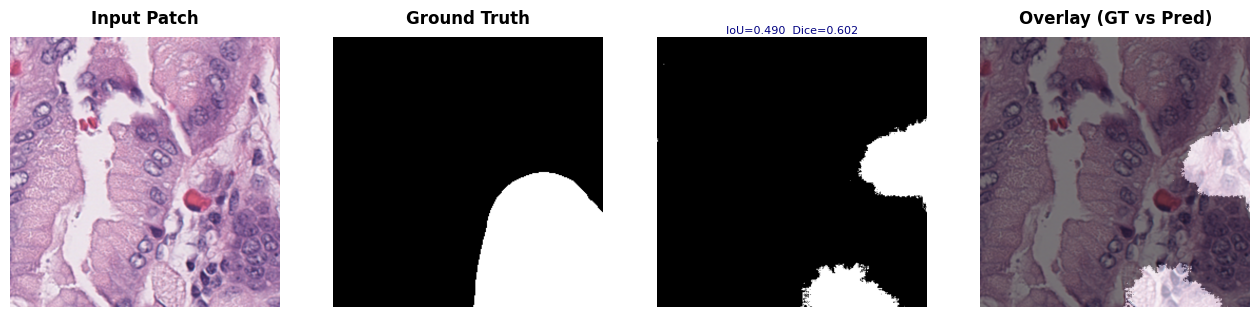

In [27]:
# ── Plot: Input | Ground Truth | Prediction | Overlay ─────────────────────────
if test_loader is not None:
    n      = 1#len(chosen)
    n_cols = 4   # Input | GT mask | Predicted mask | Overlay
    fig, axes = plt.subplots(n, n_cols, figsize=(n_cols * 4, n * 4))

    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ["Input Patch", "Ground Truth", "Predicted Mask", "Overlay (GT vs Pred)"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=12, fontweight="bold", pad=10)

    for row, (orig, gt, pred, img_idx, m) in enumerate(
            zip(test_originals, test_gt_masks, test_predictions, chosen, metrics_per_sample)):

        gt_rgb   = colorize_mask(gt,   CLASS_COLORS)
        pred_rgb = colorize_mask(pred, CLASS_COLORS)

        # Col 0: Input patch
        axes[row, 0].imshow(orig)
        axes[row, 0].set_ylabel(
            full_dataset.image_paths[img_idx].name,
            fontsize=7, rotation=0, labelpad=130, va="center")

        # Col 1: Ground truth mask
        axes[row, 1].imshow(gt_rgb)

        # Col 2: Predicted mask
        axes[row, 2].imshow(pred_rgb)
        axes[row, 2].set_title(
            f"IoU={m['iou']:.3f}  Dice={m['dice']:.3f}",
            fontsize=8, color="navy", pad=3)

        # Col 3: Side-by-side overlay
        #   Left half  = GT blended,   Right half = Pred blended
        h, w   = orig.shape[:2]
        half   = w // 2
        overlay = orig.copy()
        overlay[:, :half]  = (orig[:, :half]  * 0.5 + gt_rgb[:, :half]   * 0.5).astype(np.uint8)
        overlay[:, half:]  = (orig[:, half:]  * 0.5 + pred_rgb[:, half:] * 0.5).astype(np.uint8)
        # draw a dividing line
        # overlay[:, half-1:half+1] = [255, 0, 0]   # red divider
        axes[row, 3].imshow(overlay)
        # axes[row, 3].set_title("← GT  |  Pred →", fontsize=8, color="red", pad=3)

        for col in range(n_cols):
            axes[row, col].axis("off")

    # Legend
    legend_patches = [
        mpatches.Patch(color=[c/255 for c in CLASS_COLORS[i]], label=CLASS_NAMES[i])
        for i in range(n_cls)
    ]
    fig.legend(handles=legend_patches, loc="lower center",
               ncol=n_cls, fontsize=11, bbox_to_anchor=(0.5, -0.01), frameon=True)

    plt.suptitle(
        f"{cfg['model']['name'].upper()} — Test Set  |  "
        f"Epoch {ckpt.get('epoch','?')}  |  "
        f"Mean IoU={mean_iou_val:.4f}  Dice={mean_dice_val:.4f}",
        fontsize=14, fontweight="bold", y=1.01)

    plt.tight_layout()
    #plt.savefig("logs/test_set_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: logs/test_set_grid.png")

In [13]:
# ── Per-sample metrics table ──────────────────────────────────────────────────
if test_loader is not None:
    print(f"{'#':<4} {'Filename':<45} {'IoU':>8} {'Dice':>8} {'Acc':>8}")
    print("-" * 76)
    for i, (img_idx, pred, gt, m) in enumerate(
            zip(chosen, test_predictions, test_gt_masks, metrics_per_sample)):
        fname = full_dataset.image_paths[img_idx].name
        acc   = (pred == gt).sum() / gt.size * 100
        print(f"{i+1:<4} {fname:<45} {m['iou']:>7.4f}  {m['dice']:>7.4f}  {acc:>6.2f}%")
    print("-" * 76)
    print(f"{'Mean':<50} {mean_iou_val:>7.4f}  {mean_dice_val:>7.4f}")